In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
INPUT_LENGTH = 24
OUTPUT_LENGTH = 3

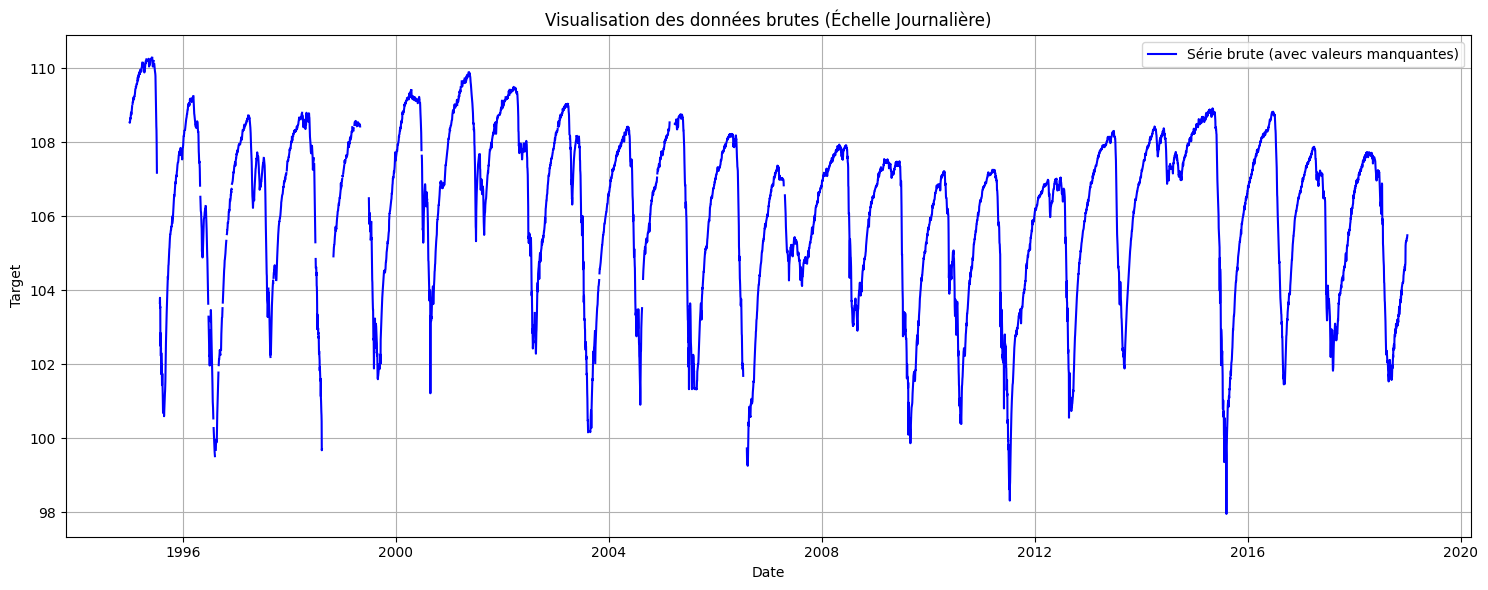

In [159]:
df_train_init = pd.read_csv(
	"train.csv", 
	sep=';', 
	parse_dates=['date'], 
	index_col='date'
)
df_test_init = pd.read_csv(
	"test.csv", 
	sep=';', 
	parse_dates=['date'], 
	index_col='date'
)
plt.figure(figsize=(15, 6))
plt.plot(df_train_init.index, df_train_init['target'], label='Série brute (avec valeurs manquantes)', color='blue')
plt.title('Visualisation des données brutes (Échelle Journalière)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

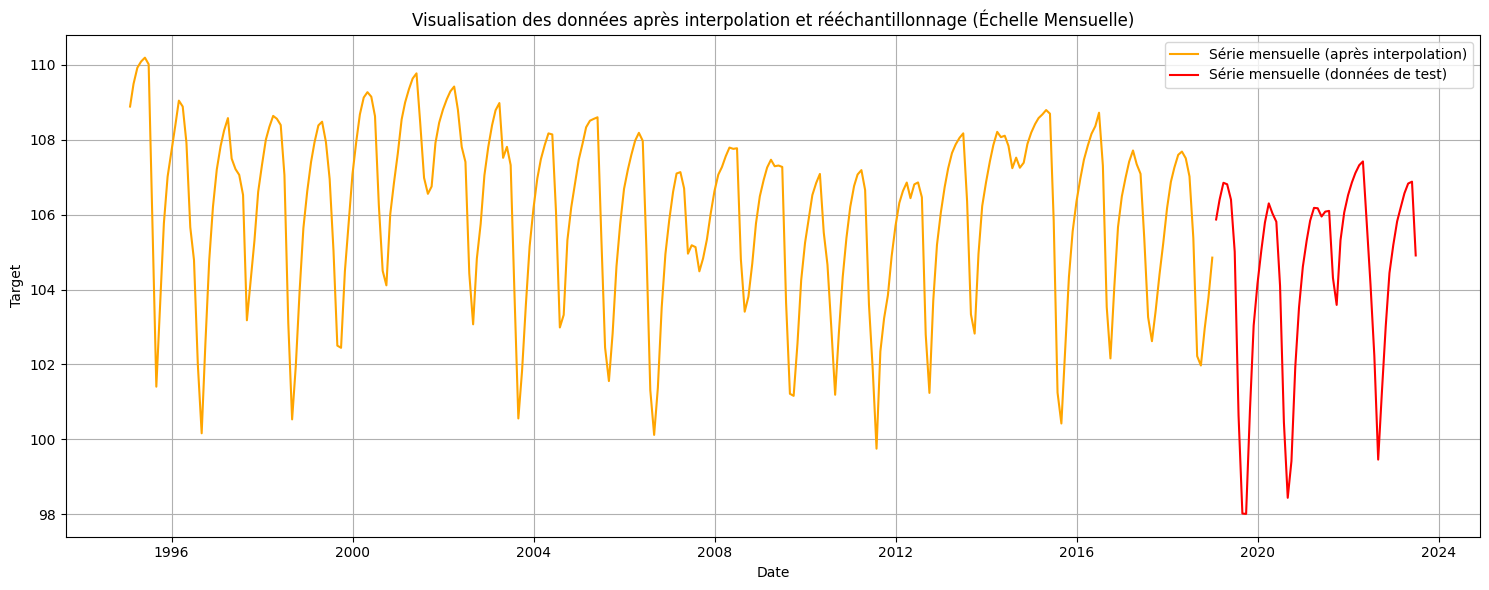

In [160]:
df_train_interpolated = df_train_init.interpolate(method='time')
df_train_monthly = df_train_interpolated.resample('ME').mean()
df_test_interpolated = df_test_init.interpolate(method='time')
df_test_monthly = df_test_interpolated.resample('ME').mean()
plt.figure(figsize=(15, 6))
plt.plot(df_train_monthly.index, df_train_monthly['target'], label='Série mensuelle (après interpolation)', color='orange')
plt.plot(df_test_monthly.index, df_test_monthly['target'], label='Série mensuelle (données de test)', color='red')
plt.title('Visualisation des données après interpolation et rééchantillonnage (Échelle Mensuelle)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.legend()
plt.tight_layout()

In [161]:
from sklearn.preprocessing import MinMaxScaler
def create_sequences(data, seq_length, target_col, output_lenght=1):
	xs = []
	ys = []
	for i in range(len(data) - seq_length - output_lenght + 1):
		x = data[target_col].iloc[i:(i + seq_length)].values
		y = data[target_col].iloc[(i + seq_length):(i + seq_length + output_lenght)].values
		xs.append(x)
		ys.append(y)
	return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)
nb_valid = 48 
df_train = df_train_monthly[:-nb_valid].copy()
df_valid = df_train_monthly[-nb_valid:].copy()
df_test = df_test_monthly.copy()
scaler = MinMaxScaler()
df_train['target'] = scaler.fit_transform(df_train[['target']])
df_valid['target'] = scaler.transform(df_valid[['target']])
df_test['target'] = scaler.transform(df_test[['target']])
trainX, trainY = create_sequences(df_train, seq_length=INPUT_LENGTH, target_col='target', output_lenght=OUTPUT_LENGTH)
validX, validY = create_sequences(df_valid, seq_length=INPUT_LENGTH, target_col='target', output_lenght=OUTPUT_LENGTH)
testX, testY = create_sequences(df_test, seq_length=INPUT_LENGTH, target_col='target', output_lenght=OUTPUT_LENGTH)

In [164]:
class Seq2Seq(nn.Module):
	def __init__(self, input_size=1, hidden_size=64, output_size=OUTPUT_LENGTH):
		super(Seq2Seq, self).__init__()
		self.encoder_lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
		self.decoder_lstm = nn.LSTM(1, hidden_size, batch_first=True)
		self.dense1 = nn.Linear(hidden_size, 32)
		self.dense2 = nn.Linear(32, output_size)
	def forward(self, x):
		x = x.unsqueeze(-1)  
		encoder_out, (hidden, cell) = self.encoder_lstm(x)
		decoder_input = torch.zeros((x.size(0), OUTPUT_LENGTH, 1), device=x.device)
		lstm2_out, _ = self.decoder_lstm(decoder_input, (hidden, cell))
		out = self.dense1(lstm2_out[:, -1, :])
		out = torch.relu(out)
		out = self.dense2(out)
		return out

In [170]:
model = Seq2Seq(input_size=1, hidden_size=64, output_size=OUTPUT_LENGTH)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 900
for epoch in range(num_epochs):
	model.train()
	outputs = model(trainX)
	loss = criterion(outputs.squeeze(), trainY)
	optimizer.zero_grad()
	loss.backward()
	optimizer.step()
	optimizer.zero_grad()
	if (epoch+1) % 10 == 0:
		with torch.no_grad():
			model.eval()
			val_outputs = model(validX)
			val_loss = criterion(val_outputs.squeeze(), validY)
			print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')
		print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
print('End!')

Epoch [10/900], Loss: 0.5103, Validation Loss: 0.4131
Epoch [10/900], Loss: 0.5103
Epoch [20/900], Loss: 0.4361, Validation Loss: 0.3413
Epoch [20/900], Loss: 0.4361
Epoch [30/900], Loss: 0.1504, Validation Loss: 0.0796
Epoch [30/900], Loss: 0.1504
Epoch [40/900], Loss: 0.0646, Validation Loss: 0.0791
Epoch [40/900], Loss: 0.0646
Epoch [50/900], Loss: 0.0502, Validation Loss: 0.0358
Epoch [50/900], Loss: 0.0502
Epoch [60/900], Loss: 0.0455, Validation Loss: 0.0455
Epoch [60/900], Loss: 0.0455
Epoch [70/900], Loss: 0.0445, Validation Loss: 0.0386
Epoch [70/900], Loss: 0.0445
Epoch [80/900], Loss: 0.0445, Validation Loss: 0.0394
Epoch [80/900], Loss: 0.0445
Epoch [90/900], Loss: 0.0445, Validation Loss: 0.0405
Epoch [90/900], Loss: 0.0445
Epoch [100/900], Loss: 0.0444, Validation Loss: 0.0391
Epoch [100/900], Loss: 0.0444
Epoch [110/900], Loss: 0.0444, Validation Loss: 0.0400
Epoch [110/900], Loss: 0.0444
Epoch [120/900], Loss: 0.0444, Validation Loss: 0.0395
Epoch [120/900], Loss: 0.044

shape of the test data:  torch.Size([28, 24]) torch.Size([28, 3])


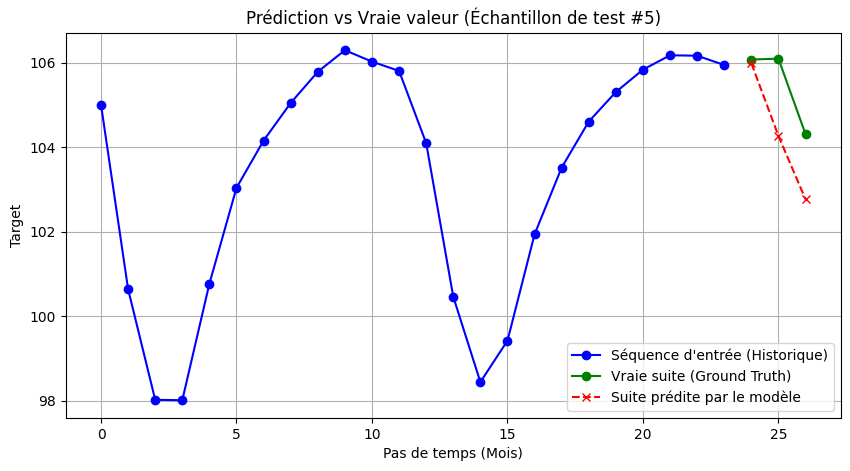

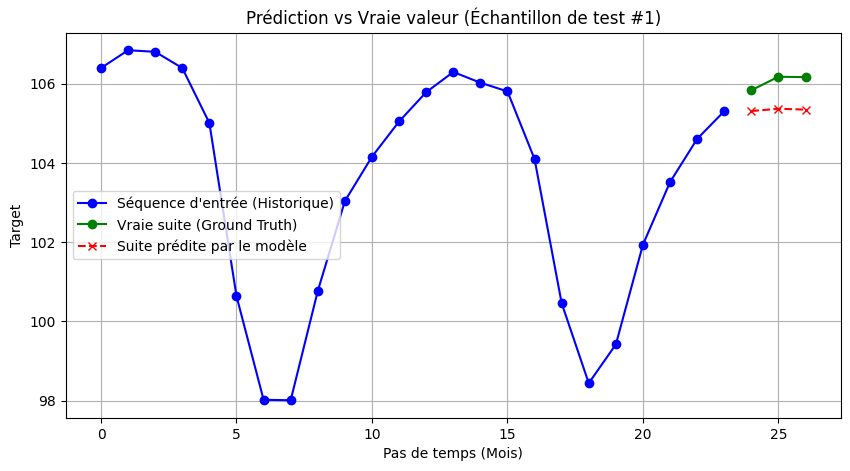

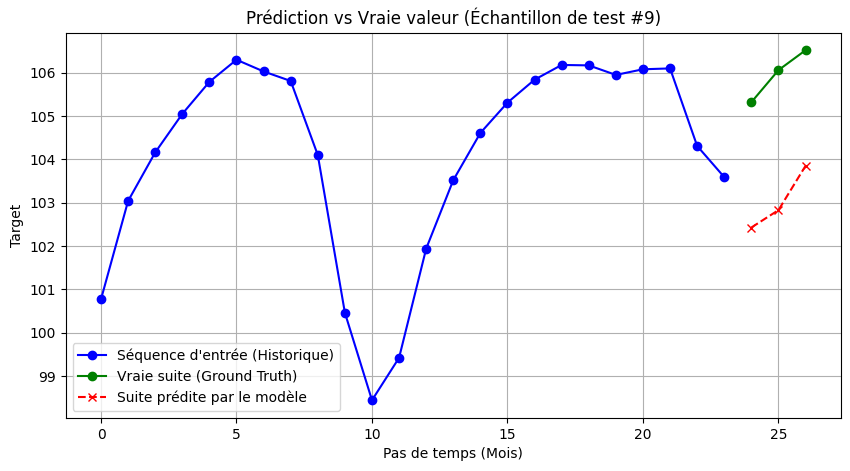

In [171]:
def plot_prediction(model, testX, testY, scaler=None, sample_idx=0):
	model.eval()
	with torch.no_grad():
		predictions = model(testX)
	input_seq = testX[sample_idx].squeeze().numpy() 
	true_target = testY[sample_idx].squeeze().numpy()   
	pred_target = predictions[sample_idx].squeeze().numpy() 
	if scaler is not None:
		input_seq = scaler.inverse_transform(input_seq.reshape(-1, 1)).flatten()
		true_target = scaler.inverse_transform(true_target.reshape(-1, 1)).flatten()
		pred_target = scaler.inverse_transform(pred_target.reshape(-1, 1)).flatten()
	time_input = np.arange(len(input_seq))
	time_target = np.arange(len(input_seq), len(input_seq) + len(true_target))
	plt.figure(figsize=(10, 5))
	plt.plot(time_input, input_seq, label='Séquence d\'entrée (Historique)', color='blue', marker='o')
	plt.plot(time_target, true_target, label='Vraie suite (Ground Truth)', color='green', marker='o')
	plt.plot(time_target, pred_target, label='Suite prédite par le modèle', color='red', linestyle='--', marker='x')
	plt.title(f'Prédiction vs Vraie valeur (Échantillon de test
	plt.xlabel('Pas de temps (Mois)')
	plt.ylabel('Target')
	plt.legend()
	plt.grid(True)
	plt.show()
print("shape of the test data: ", testX.shape, testY.shape)
plot_prediction(model, testX, testY, scaler=scaler, sample_idx=5)
plot_prediction(model, testX, testY, scaler=scaler, sample_idx=1)
plot_prediction(model, testX, testY, scaler=scaler, sample_idx=9)